Load libs

In [9]:
import os
import random
from tqdm import tqdm
from PIL import Image
from transformers import pipeline
from huggingface_hub import login
from transformers.image_utils import load_image
from dotenv import load_dotenv
from sklearn.decomposition import PCA
import numpy as np
from matplotlib import pyplot as plt
from scipy.ndimage import gaussian_filter
from typing import List

load_dotenv()
login(token=os.getenv('HF_TOKEN'))

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Load dataset

In [10]:
TEST_IMAGE_DIR = 'data/toothbrush/test'

image_paths = []

for root, dir, files in os.walk(TEST_IMAGE_DIR):
    for file in files:
        if file.endswith('.png') or file.endswith('.jpg'):
            image_paths.append(os.path.join(root, file))

print(image_paths[:3])

['data/toothbrush/test/defective/002.png', 'data/toothbrush/test/defective/016.png', 'data/toothbrush/test/defective/017.png']


Inspect images from dataset

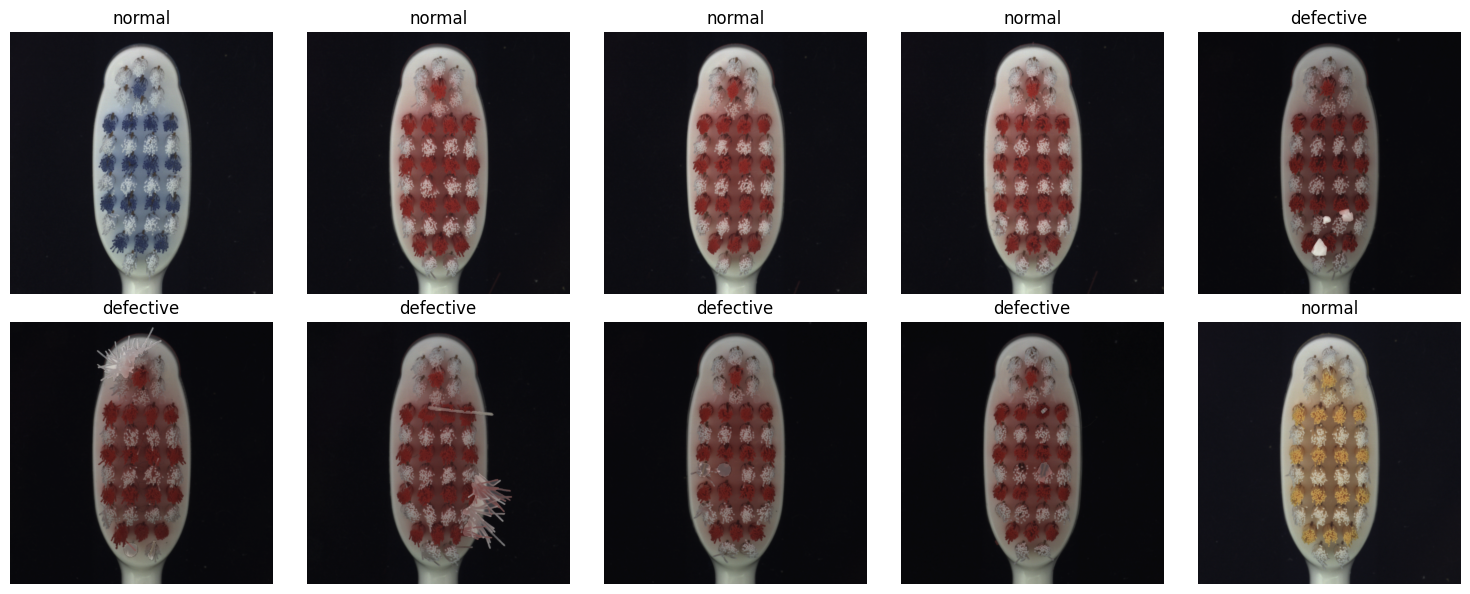

In [11]:
random.shuffle(image_paths)


fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, image_path in zip(axes.flatten(), image_paths[:10]):
    label = 'normal' if 'good' in image_path else 'defective'
    ax.set_title(label)
    img = Image.open(image_path)
    ax.imshow(img)
    ax.axis('off')
    if label == 'defective':
        # load the ground truth mask
        gt_path = image_path.replace('test', 'ground_truth').replace('.png', '_mask.png')
        gt_img = Image.open(gt_path)
        gt_img = gt_img.point(lambda x: 0 if x < 128 else 255, '1')
        ax.imshow(gt_img, alpha=0.2)


plt.tight_layout()
plt.show()

Loading the model

In [12]:
MODEL_NAME = "facebook/dinov3-vits16-pretrain-lvd1689m"

feature_extractor = pipeline(
    model=MODEL_NAME,
    task="image-feature-extraction",
)

Device set to use mps:0


Example inference

In [13]:
image = load_image(image_paths[0])

features = np.array(feature_extractor(image))
print('Inference features shape: (batch_size, tokens, feature_dim)')
print(features.shape)
print('Tokens:  1 class token + 4 register tokens + 196 patch tokens = 201 tokens')

Inference features shape: (batch_size, tokens, feature_dim)
(1, 201, 384)
Tokens:  1 class token + 4 register tokens + 196 patch tokens = 201 tokens


Experimenting with masking the background

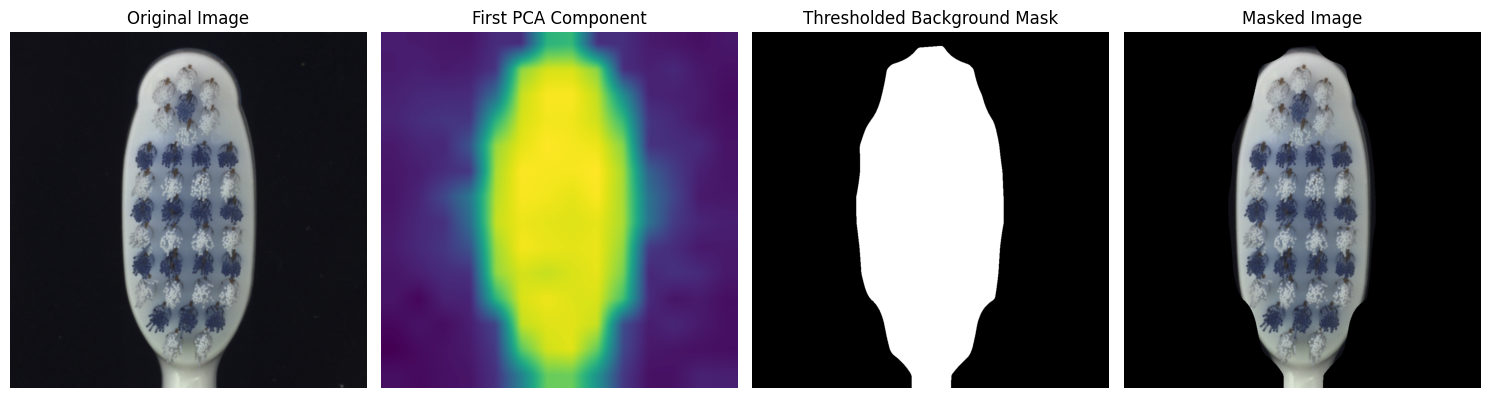

In [14]:
def mask_bg(image, patch_features, threshold_percentile=70, smoothing_sigma=4):
    # Perform PCA
    pca = PCA(n_components=1)
    pca_components = pca.fit_transform(patch_features)  # shape: (196, 1)

    # Reshape to shape of image
    width, height = image.size  # (width, height)
    patch_grid_size = int(np.sqrt(patch_features.shape[0]))  # 14
    pca_map = pca_components.reshape(patch_grid_size, patch_grid_size)

    # Upsample to original image size using PIL
    pca_map_img = Image.fromarray(pca_map.astype(np.float32))
    pca_map_img = pca_map_img.resize((width, height), Image.BILINEAR)
    # apply gaussian smoothing
    pca_map_img = gaussian_filter(np.array(pca_map_img), sigma=smoothing_sigma)
    pca_map = np.array(pca_map_img)

    # Apply threshold
    threshold = np.percentile(pca_map, threshold_percentile)
    bg_mask = pca_map > threshold

    # Apply mask to original image
    masked_image = np.array(image) * bg_mask[..., np.newaxis]
    
    return pca_map, bg_mask, masked_image

# Extract patch tokens (exclude class token and register tokens)
patch_features = features[0, 5:, :]  # shape: (196, 384)
pca_map, bg_mask, masked_image = mask_bg(image, patch_features)

# Visualize
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
axes[0].imshow(image)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(pca_map, cmap='viridis')
axes[1].set_title('First PCA Component')
axes[1].axis('off')

axes[2].imshow(bg_mask, cmap='gray')
axes[2].set_title('Thresholded Background Mask')
axes[2].axis('off')

axes[3].imshow(masked_image)
axes[3].set_title('Masked Image')
axes[3].axis('off')

plt.tight_layout()
plt.show()

## Batched Zero-shot setting

The underlying (and necessary) assumption to meaningfully predict anomalies solely based on test samples, is that the majority of samples (or in our case, patches) at test time are from the nominal data distribution (see e.g., Li et al., 2024a).

In [21]:
def batched_zero_shot_anomaly_detection(images:List[Image.Image], feature_extractor):
    num_images = len(images)
    # Embed all test images as one batch
    all_patch_features = []
    for image in tqdm(images, total=num_images):
        features = np.array(feature_extractor(image))
        patch_features = features[0, 5:, :]  # shape: (196, 384)
        all_patch_features.append(patch_features)

    all_patch_features = np.array(all_patch_features) 
    print('All patch features shape:', all_patch_features.shape)

    hidden_dim = all_patch_features.shape[-1]

    image_level_scores = []

    for i in range(num_images):
        # 1. Select the patches for the current test image
        test_patches = all_patch_features[i, :, :]  # Shape: (num_patches, hidden_dim)
        
        # 2. Create the memory bank from ALL OTHER images
        filter_i = np.arange(num_images) != i
        memory_bank_patches = all_patch_features[filter_i]
        
        # Reshape bank to ( (num_images - 1) * num_patches, hidden_dim )
        memory_bank = memory_bank_patches.reshape(-1, hidden_dim)

        # 3. Calculate cosine distances (1 - similarity)
        # We want a matrix of shape (num_test_patches, num_bank_patches)
        
        # Normalize vectors for cosine similarity calculation
        test_patches_norm = test_patches / (np.linalg.norm(test_patches, axis=1, keepdims=True) + 1e-10)
        memory_bank_norm = memory_bank / (np.linalg.norm(memory_bank, axis=1, keepdims=True) + 1e-10)
        
        # Similarities shape: (num_patches, num_bank_patches)
        similarities = np.dot(test_patches_norm, memory_bank_norm.T)
        
        # Distances shape: (num_patches, num_bank_patches)
        distances = 1 - similarities

        # 4: Calculate Patch-Level Scores
        # For EACH test patch, find the mean of its 0.1% lowest distances to the bank 
        
        k_patch = max(1, int(0.001 * memory_bank.shape[0]))
        
        # Partition each ROW (axis=1) to find the k_patch smallest distances
        partitioned_distances = np.partition(distances, k_patch, axis=1)
        
        # Select the k_patch smallest distances for each patch
        lowest_k_distances = partitioned_distances[:, :k_patch]
        
        # Average them to get the score for each patch
        # patch_scores shape: (num_patches,)
        patch_scores = np.mean(lowest_k_distances, axis=1)
        
        # 5: Calculate Image-Level Score
        # Aggregate patch scores to a single image score
        # Use the mean of the 1% HIGHEST patch scores 
        
        k_image = max(1, int(0.01 * patch_scores.shape[0]))
        
        # Partition the patch_scores array to find the k_image largest scores
        highest_k_patch_scores = np.partition(patch_scores, -k_image)[-k_image:]
        
        # Average them to get the final image-level score
        image_level_anomaly_score = np.mean(highest_k_patch_scores)
        
        image_level_scores.append(float(image_level_anomaly_score))

    return np.array(image_level_scores)

In [22]:
images = [load_image(path) for path in image_paths]
anomaly_scores = batched_zero_shot_anomaly_detection(images, feature_extractor)
print('Anomaly scores:', anomaly_scores)

100%|██████████| 42/42 [00:01<00:00, 28.41it/s]


All patch features shape: (42, 196, 384)
Anomaly scores: [0.06756782 0.08736928 0.06574791 0.05580956 0.11363433 0.10702656
 0.13345387 0.1053149  0.05995579 0.05065068 0.05605719 0.10174936
 0.15971028 0.16209306 0.05935026 0.12129189 0.13026441 0.13433257
 0.0594719  0.1277029  0.12734456 0.0433678  0.05061907 0.12951247
 0.06177963 0.08773263 0.1396692  0.11853265 0.13448807 0.13939674
 0.0570387  0.15821714 0.0469939  0.12497812 0.11880783 0.13680059
 0.18274368 0.09157355 0.08934032 0.09634871 0.11033092 0.08128045]


In [ ]:
OBJECT_TYPES = [
    'bottle',
    'cable',
    'capsule',
    'carpet',
    'grid',
    'hazelnut',
    'leather',
    'metal_nut',
    'pill',
    'screw',
    'tile',
    'toothbrush',
    'transistor',
    'wood',
    'zipper',
]

MASKED_OBJECTS = [ # the classes on which masking makes sense according to AnomalyDINO paper
    'capsule',
    'hazelnut',
    'pill',
    'screw',
    'toothbrush',
]

SELECTED_OBJECTS = ['bottle'] # or None to process all object types
# SELECTED_OBJECTS = None  # or None to process all object types

def main(selected=SELECTED_OBJECTS):
    if selected is None:
        selected = OBJECT_TYPES

    for object_type in tqdm(selected, desc='Processing selected object types', total=len(selected)):
        print(f'Processing object type: {object_type}')
        img_dir = f'data/{object_type}/test'
        image_paths = []
        for root, dir, files in os.walk(img_dir):
            for file in files:
                if file.endswith('.png') or file.endswith('.jpg'):
                    image_paths.append(os.path.join(root, file))

        images = [load_image(path) for path in image_paths]

        if object_type in MASKED_OBJECTS:
            print(f'Applying background masking for {object_type}s')    
            features = np.array([feature_extractor(image) for image in images])
            masked_images = []
            for image, features in zip(images, features):
                patch_features = np.array(features[0, 5:, :])  # shape: (196, 384)
                _, _, masked_image = mask_bg(image, patch_features)
                masked_images.append(Image.fromarray(masked_image))
            images = masked_images

        anomaly_scores = batched_zero_shot_anomaly_detection(images, feature_extractor)

        # save score to /test_scores/{object_type}_scores.npy
        save_dir = f'test_scores/zero_shot/{MODEL_NAME.split("/")[-1]}'
        os.makedirs(save_dir, exist_ok=True)
        score_path = os.path.join(save_dir, f'{object_type}.npy')
        np.save(score_path, anomaly_scores)

main(SELECTED_OBJECTS)

Processing selected object types:   0%|          | 0/1 [00:00<?, ?it/s]

Processing object type: bottle


100%|██████████| 83/83 [00:02<00:00, 28.48it/s]


All patch features shape: (83, 196, 384)
